# Final AI/ML Project

# CoreTech AI Customer Churn Intelligence Platform
Customer churn is one of the most critical challenges faced by modern businesses. Retaining existing customers is often more cost-effective than acquiring new ones.

This project develops an AI-powered Customer Churn Intelligence Platform capable of predicting customer churn behavior using machine learning techniques. The project includes data preprocessing, exploratory data analysis, feature engineering, model training, hyperparameter optimization, model comparison, business insights generation, and deployment preparation.

The objective is not only to predict churn but also to identify high-risk customers and provide actionable business intelligence for retention strategies.

----------------------------------------------------------------------------------------------------------
# Import Required Libraries

The following libraries are imported for data processing, visualization, machine learning, model evaluation, and optimization.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Load Dataset

The Telco Customer Churn dataset is loaded into the environment. This dataset contains customer demographic information, service subscriptions, billing details, and churn status.

In [ ]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Dataset Overview

In [ ]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.info()

Rows and Columns:
(7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   Onl

## Dataset Interpretation

The dataset contains customer demographic, subscription, service usage, and billing information. The target variable is Churn, which indicates whether a customer left the company or remained active.

Understanding the dataset structure helps identify data quality issues and prepares the data for preprocessing and modeling.

------------------------------------------------------------------------------------------------------

# Missing Values Analysis

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


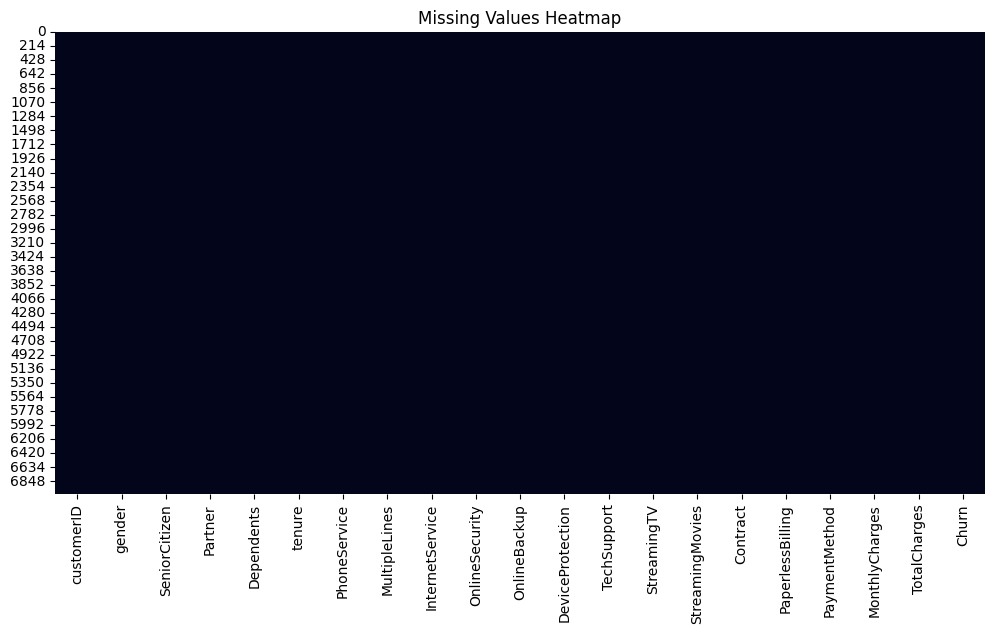

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title(
    "Missing Values Heatmap"
)

plt.show()

## Missing Value Analysis

Missing values can negatively affect machine learning performance, but this Data Set has not any missing or null value.



----------------------------------------------------------------------------------------------
# Duplicate Records


In [ ]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


### Duplicate Record Analysis

Duplicate records may introduce bias and distort model learning. The dataset is examined to ensure data integrity before proceeding with further analysis (Our Data Set has not any duplicate Record).

-----------------------------------------------------------------------------------------
## Data Cleaning

The TotalCharges column was converted into numerical format and missing values were replaced using the median value. This ensures consistency and improves model readiness.

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

/tmp/ipykernel_1389/3609252841.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


# Target Variable Analysis


## Churn Distribution Analysis
Understanding the distribution of the target variable is essential before model training. This analysis helps determine whether customer churn is a major business concern and whether the dataset is balanced enough for predictive modeling.

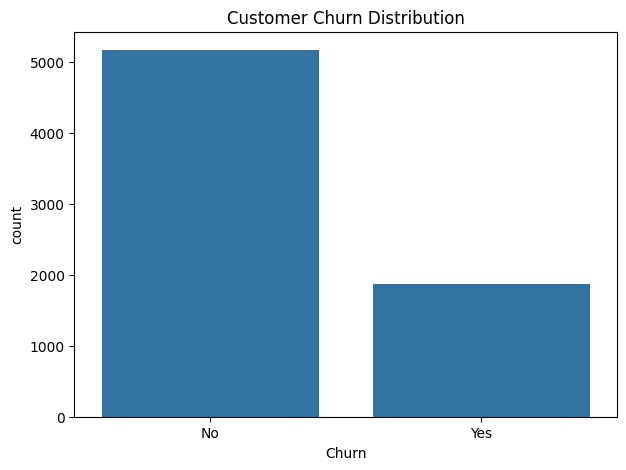

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Churn",
    data=df
)

plt.title(
    "Customer Churn Distribution"
)

plt.savefig(
    "churn_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Churn Distribution Interpretation

The churn distribution analysis shows that a significantly larger number of customers remained with the company compared to those who churned. The dataset contains both churned and retained customers, making it suitable for supervised machine learning classification.

Although the classes are not perfectly balanced, the churned customer group is sufficiently represented to enable effective model training and evaluation.

----------------------------------------------------------------------------------------------------


# Customer Retention Percentage Analysis

This analysis examines the percentage of customers who stayed with the company and those who left. Understanding these proportions provides valuable insight into overall customer retention performance.

In [ ]:
churn_percent = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percent)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


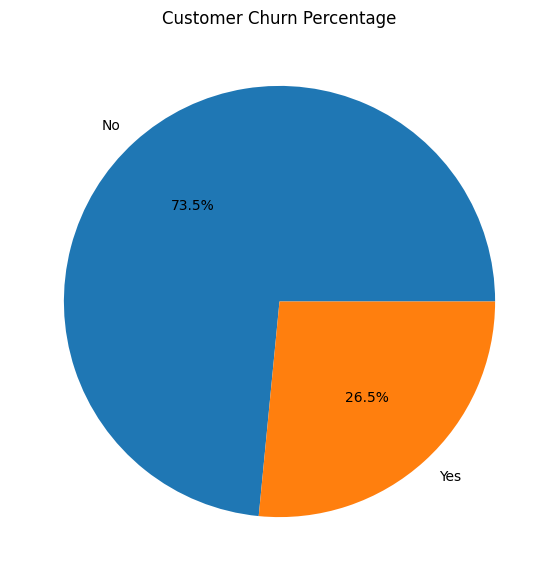

In [ ]:
plt.figure(figsize=(7,7))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "Customer Churn Percentage"
)

plt.savefig(
    "churn_percentage.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Business Interpretation

The analysis reveals that approximately 73.5% of customers remained with the company, while 26.5% of customers churned.

This indicates that nearly one out of every four customers discontinued services, representing a substantial business challenge. Customer churn at this level can directly impact revenue, profitability, and long-term growth.

These findings highlight the importance of developing predictive models capable of identifying high-risk customers before they leave, enabling proactive retention strategies and improved customer relationship management.

----------------------------------------------------------------------------------

# Contract Type vs Customer Churn Analysis

Contract duration is one of the most important factors affecting customer retention. This analysis investigates how different contract types influence customer churn behavior and loyalty.

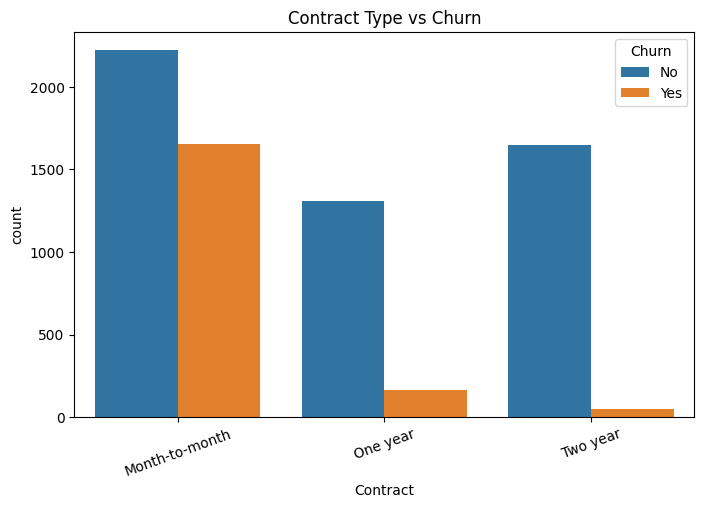

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)

plt.title(
    "Contract Type vs Churn"
)

plt.savefig(
    "contract_vs_churn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Contract Analysis Interpretation

The visualization reveals a strong relationship between contract type and customer churn.

Customers subscribed to month-to-month contracts exhibit the highest churn rate, indicating that short-term commitments are associated with increased customer turnover. In contrast, customers with one-year and two-year contracts demonstrate significantly lower churn rates, suggesting stronger loyalty and long-term engagement.

This pattern indicates that contract duration plays a critical role in customer retention and should be considered a key predictor in churn modeling.

### Executive Summary

Contract type appears to be one of the strongest business drivers of churn within the dataset. The results indicate that customer retention improves substantially as contract duration increases, making contract strategy a potential area for business optimization and revenue protection.

-----------------------------------------------------------------------------------

# Monthly Charges vs Customer Churn Analysis



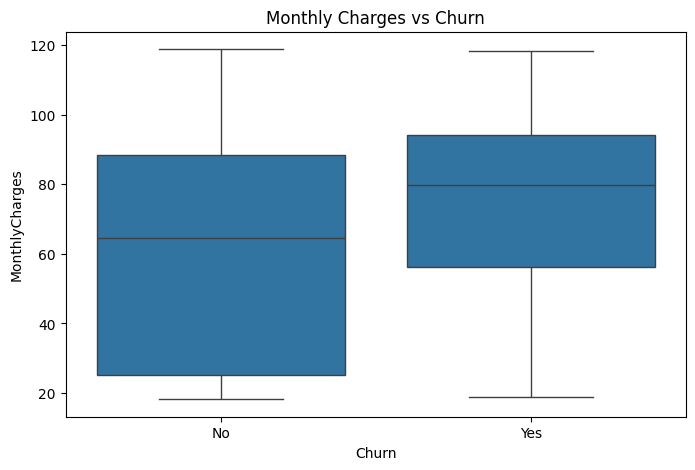

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title(
    "Monthly Charges vs Churn"
)

plt.savefig(
    "monthly_charges_vs_churn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Monthly Charges Analysis Interpretation

The boxplot shows a noticeable difference between the monthly charges of churned and retained customers.

Customers who churned generally exhibit higher monthly charges compared to customers who remained with the company. The median monthly charge for churned customers is significantly higher, suggesting that pricing may influence customer satisfaction and retention decisions.

This relationship indicates that customers paying higher service fees may be more sensitive to perceived value, service quality, or competing alternatives in the market.

## Analytical Observation

The wider distribution observed among retained customers indicates that both low-cost and high-cost customers can remain loyal. However, the higher median monthly charge among churned customers suggests that pricing pressure may contribute to customer attrition and should be further investigated during feature importance analysis.

-------------------------------------------------------------------------------------------------

# Customer Tenure Analysis

Customer tenure represents the length of time a customer has remained with the company. It is one of the most important indicators of customer loyalty, engagement, and long-term retention.

This analysis investigates how customer tenure influences churn behavior.

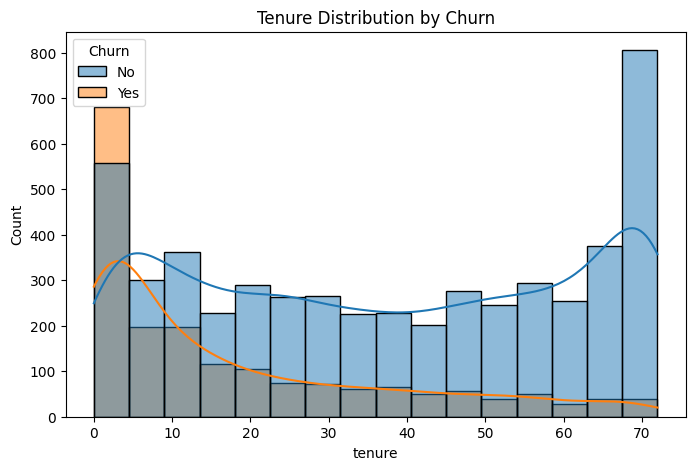

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True
)

plt.title(
    "Tenure Distribution by Churn"
)

plt.savefig(
    "tenure_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Tenure Analysis Interpretation

The tenure distribution reveals a strong relationship between customer longevity and churn behavior.

Customers with very short tenure periods exhibit significantly higher churn rates, indicating that new customers are more likely to leave the company during the early stages of their customer journey. In contrast, customers with longer tenure periods show substantially lower churn rates and demonstrate stronger loyalty.

The results suggest that customer retention improves as the customer relationship matures, making tenure one of the most valuable predictors of churn.

# Analytical Observation

The churn distribution exhibits a clear negative relationship with tenure. As customer tenure increases, the probability of churn decreases substantially.

This pattern suggests that customer loyalty strengthens over time and supports the development of retention strategies specifically targeted at newly acquired customers, where churn risk is highest.

---------------------------------------------------------------------------------------------

# Senior Citizen Analysis

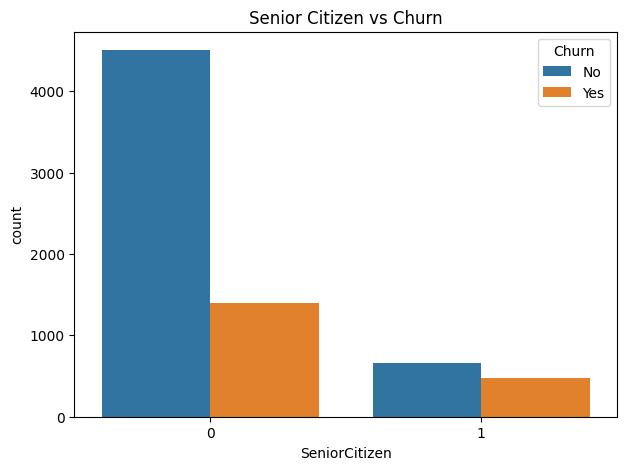

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title(
    "Senior Citizen vs Churn"
)

plt.savefig(
    "seniorcitizen_vs_churn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

##Analytical Observation

Customer churn is influenced by multiple factors beyond pricing and tenure. Demographic attributes such as age group can interact with service preferences, technology adoption, and customer expectations, creating different retention patterns across customer segments.

Further analysis through machine learning feature importance will help determine the true predictive power of the SeniorCitizen feature.

##Key Business Insight

Senior citizens may require more personalized support and customer engagement strategies compared to other customer groups.

Organizations can improve retention by offering simplified service plans, dedicated customer support channels, and targeted loyalty programs designed specifically for senior customers.

------------------------------------------------------------------------------------------------

#Correlation Analysis

First encode for correlation only:

In [ ]:
corr_df = df.copy()

for col in corr_df.columns:

    if corr_df[col].dtype == "object":

        le = LabelEncoder()

        corr_df[col] = le.fit_transform(
            corr_df[col]
        )

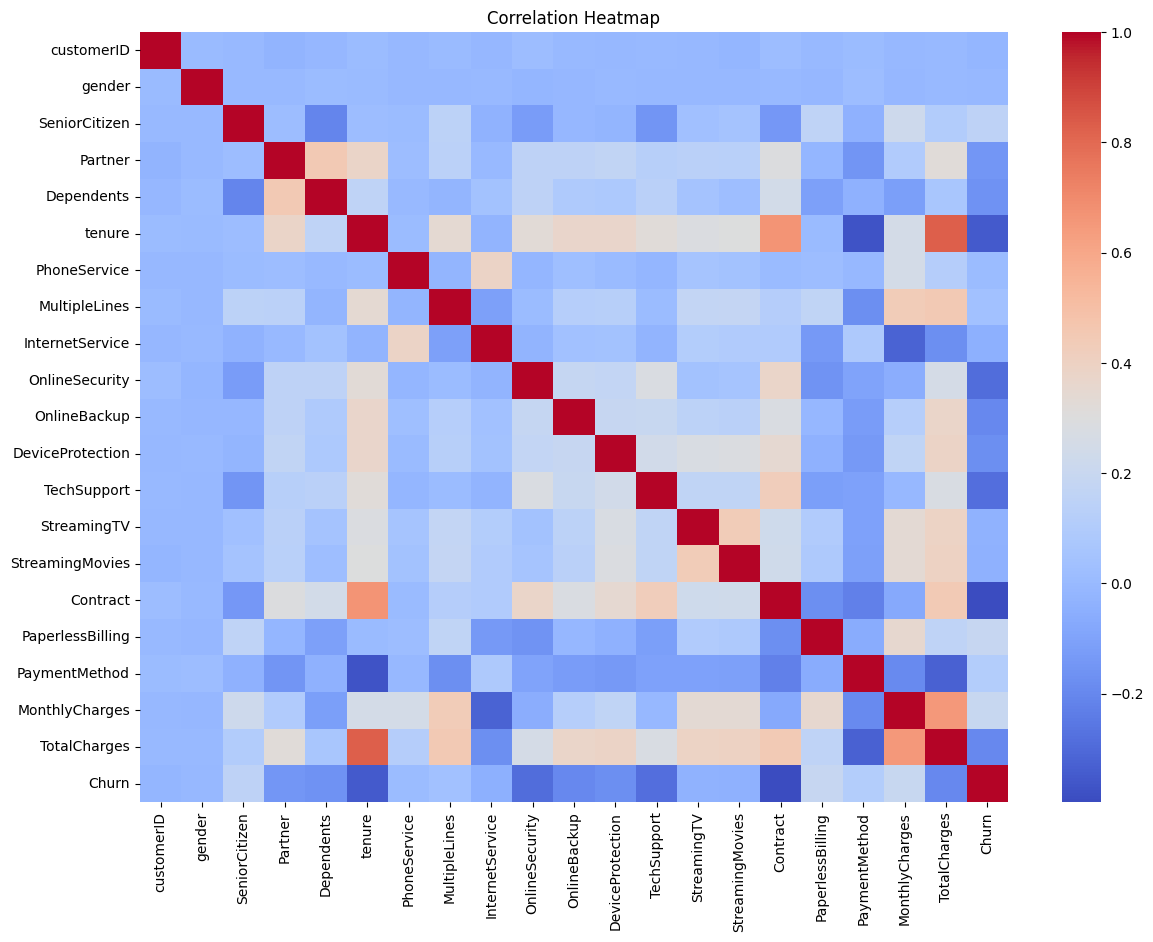

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_df.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Correlation Heatmap Interpretation

The correlation heatmap provides a comprehensive overview of relationships between customer attributes and churn behavior.

Several variables demonstrate meaningful associations with customer churn, including contract type, tenure, monthly charges, internet-related services, and total charges. These relationships indicate that both customer engagement and service characteristics influence retention outcomes.

The heatmap also reveals correlations among service-related features, suggesting that customers who subscribe to multiple services often exhibit different retention patterns compared to customers using fewer services.

Correlation analysis serves as an important foundation for feature selection, feature engineering, and predictive model development.

## Analytical Observation

The heatmap indicates that some service-related features are positively correlated with one another, reflecting common customer subscription patterns. Such relationships may provide valuable predictive information when combined through feature engineering techniques.

Furthermore, variables demonstrating stronger associations with churn are expected to contribute significantly to model performance and business insight generation.

---------------------------------------------------------------------------------------------------

# Top Factors Related to Churn

In [ ]:
corr_target = corr_df.corr()["Churn"]

print(
    corr_target.sort_values(
        ascending=False
    )
)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
customerID         -0.017447
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199037
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


## Correlation Analysis Interpretation

The correlation results reveal several important factors influencing customer churn.

Among all variables, Contract (-0.397), Tenure (-0.352), Online Security (-0.289), and Technical Support (-0.282) exhibit the strongest negative relationships with churn. This indicates that customers with longer contracts, longer service durations, online security services, and technical support subscriptions are less likely to leave the company.

Conversely, Monthly Charges (0.193), Paperless Billing (0.191), and Senior Citizen status (0.151) demonstrate positive relationships with churn, suggesting that these factors may increase customer attrition risk.

##Strategic Recommendation

Organizations should prioritize converting month-to-month customers into long-term contracts, encourage adoption of security and support services, and implement retention campaigns targeting high-risk customers with short tenure periods.

These initiatives have the potential to significantly reduce customer churn and improve long-term revenue stability.

--------------------------------------------------------------------------------------------

### Download All EDA Graphs

In [ ]:
from google.colab import files

graphs = [

    "churn_distribution.png",

    "churn_percentage.png",

    "contract_vs_churn.png",

    "monthly_charges_vs_churn.png",

    "tenure_distribution.png",

    "seniorcitizen_vs_churn.png",

    "correlation_heatmap.png"

]

for graph in graphs:

    files.download(graph)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--------------------------------------------------------------------------------------------

#ADVANCED FEATURE ENGINEERING

# Feature Engineering: Customer Lifetime Value

Customer Lifetime Value (CLV) estimates the total revenue generated by a customer during their relationship with the company.

This feature combines customer tenure and monthly charges to create a more informative business metric.

In [ ]:
df["CustomerLifetimeValue"] = (
    df["tenure"]
    *
    df["MonthlyCharges"]
)

df[
    [
        "tenure",
        "MonthlyCharges",
        "CustomerLifetimeValue"
    ]
].head()

,tenure,MonthlyCharges,CustomerLifetimeValue
0,1,29.85,29.85
1,34,56.95,1936.30
2,2,53.85,107.70
3,45,42.30,1903.50
4,2,70.70,141.40


## Feature Interpretation

Customer Lifetime Value provides a more comprehensive measure of customer contribution than individual billing variables. Customers with higher CLV generally represent greater long-term business value and should receive special retention attention.

-------------------------------------------------------------------------------------------------



# Feature Engineering: Loyalty Score

Customer loyalty is estimated using customer tenure and contract commitment. Longer relationships and stronger contractual commitments are expected to indicate greater loyalty.

In [ ]:
contract_map = {

    "Month-to-month":1,

    "One year":2,

    "Two year":3

}

df["ContractScore"] = (
    df["Contract"]
    .map(contract_map)
)

df["LoyaltyScore"] = (

    df["tenure"]

    *

    df["ContractScore"]

)

df[
    [
        "tenure",
        "Contract",
        "LoyaltyScore"
    ]
].head()

,tenure,Contract,LoyaltyScore
0,1,Month-to-month,1
1,34,One year,68
2,2,Month-to-month,2
3,45,One year,90
4,2,Month-to-month,2


## Loyalty Score Interpretation

The Loyalty Score combines customer duration and contract strength into a single metric. Customers with higher loyalty scores are expected to exhibit lower churn risk and stronger long-term engagement.

--------------------------------------------------------------------------------------------------



# Feature Engineering: Revenue Segmentation

Customers contribute differently to company revenue. Segmenting customers into revenue categories helps identify valuable customer groups and enables targeted retention strategies.

This feature classifies customers into different revenue tiers based on their monthly charges.

In [ ]:
df["RevenueSegment"] = pd.qcut(

    df["MonthlyCharges"],

    q=4,

    labels=[

        "Low Revenue",

        "Medium Revenue",

        "High Revenue",

        "Premium Revenue"

    ]

)

df["RevenueSegment"].value_counts()

,count
RevenueSegment,
Medium Revenue,1766
Low Revenue,1762
Premium Revenue,1758
High Revenue,1757


## Revenue Segmentation Interpretation

Revenue segmentation helps distinguish customers based on their financial contribution to the business.

Premium customers generate higher recurring revenue and may require special retention strategies due to their greater business value.

-------------------------------------------------------------------------------------------------


# Feature Engineering: Customer Risk Score

A risk score is created to estimate customer churn vulnerability based on important churn-related indicators identified during correlation analysis.

In [ ]:
df["RiskScore"] = (

    (72 - df["tenure"])

    +

    (df["MonthlyCharges"] / 10)

)

In [ ]:
df[ ["tenure", "MonthlyCharges","RiskScore"] ].head()

,tenure,MonthlyCharges,RiskScore
0,1,29.85,73.985
1,34,56.95,43.695
2,2,53.85,75.385
3,45,42.30,31.230
4,2,70.70,77.070


## Risk Score Interpretation

Customers with shorter tenure and higher monthly charges generally exhibit higher churn risk.

The Risk Score provides an intuitive business metric for identifying potentially vulnerable customers before churn occurs.

-------------------------------------------------------------------------------------------------


# Customer Risk Categorization

To support business decision-making, customers are grouped into risk categories based on their calculated risk scores.

In [ ]:
df["RiskCategory"] = pd.qcut(

    df["RiskScore"],

    q=3,

    labels=[

        "Low Risk",

        "Medium Risk",

        "High Risk"

    ]

)

df["RiskCategory"].value_counts()

,count
RiskCategory,
Low Risk,2349
High Risk,2348
Medium Risk,2346


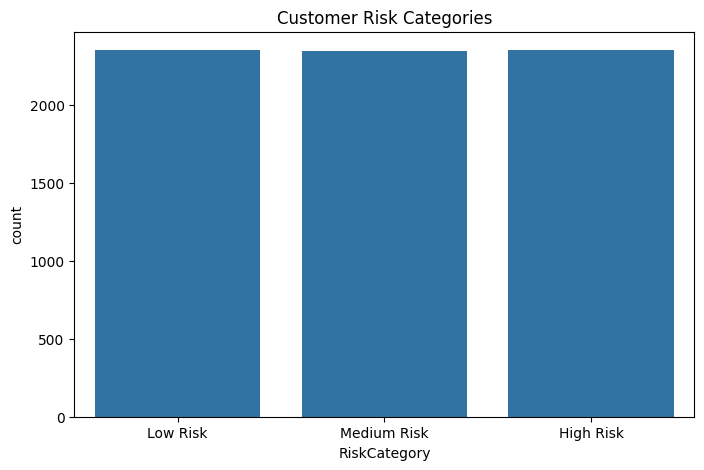

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(

    x="RiskCategory",

    data=df

)

plt.title(

    "Customer Risk Categories"

)

plt.savefig(

    "risk_categories.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Risk Category Analysis

Risk categorization transforms numerical risk scores into actionable business segments.

This enables organizations to prioritize retention efforts on high-risk customers while maintaining engagement with medium- and low-risk groups.

-------------------------------------------------------------------------------------------------


# Premium Customer Identification

Premium customers represent high-value customers who generate substantial revenue and maintain long-term relationships with the company.

Identifying premium customers is important for retention planning and customer value management.

In [ ]:
df["PremiumCustomer"] = np.where(

    (df["MonthlyCharges"] > 80)

    &

    (df["tenure"] > 24),

    1,

    0

)

df["PremiumCustomer"].value_counts()

,count
PremiumCustomer,
0,5196
1,1847


## Premium Customer Analysis

Premium customers contribute significantly to business revenue and should be considered strategic assets.

Losing premium customers may have a greater financial impact than losing standard customers, making retention efforts especially important for this segment.

-------------------------------------------------------------------------------------------------


# Feature Engineering Summary

The project now includes several engineered features designed to improve predictive performance and business intelligence capabilities.

New Features Created:

- CustomerLifetimeValue
- LoyaltyScore
- RevenueSegment
- RiskScore
- RiskCategory
- PremiumCustomer

These engineered features provide additional information beyond the original dataset and help the model better capture customer behavior patterns.

-------------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------------


In [ ]:
# Download Feature Engineering Graphs
from google.colab import files

files.download(

    "risk_categories.png"

)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Encode Categorical Variables

In [32]:
df_model = df.copy()

le = LabelEncoder()

for col in df_model.columns:

    if df_model[col].dtype == "object":

        df_model[col] = le.fit_transform(

            df_model[col]

        )

### Encoding Interpretation

Encoding converts categorical information into machine-readable numerical values while preserving the structure of the dataset.

This step prepares the data for machine learning model training.

-------------------------------------------------------------------------------------------------


# Feature Selection

The dataset is separated into independent variables (features) and the target variable (churn).

In [33]:
X = df_model.drop(

    "Churn",

    axis=1

)

y = df_model["Churn"]

print(

    "Features Shape:",

    X.shape

)

print(

    "Target Shape:",

    y.shape

)

Features Shape: (7043, 27)
Target Shape: (7043,)


# Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

## Dataset Partitioning

The training dataset is used to learn patterns, while the testing dataset is reserved for unbiased performance evaluation.

This approach helps assess model generalization capability.

-------------------------------------------------------------------------------------------------


# Feature Scaling

Numerical features are standardized to ensure consistent feature magnitudes and improve model performance.

In [38]:
for col in X_train.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Scaling Interpretation

Feature scaling prevents variables with larger numerical ranges from dominating the learning process and improves algorithm stability.

# Data Preparation Summary

The dataset has successfully completed preprocessing and feature engineering stages.

Key preprocessing activities included:

- Data quality assessment
- Data cleaning
- Feature engineering
- Revenue segmentation
- Risk score generation
- Customer categorization
- Categorical encoding
- Feature scaling
- Train-test splitting

The dataset is now fully prepared for machine learning model development and predictive analysis.

-------------------------------------------------------------------------------------------------


# MACHINE LEARNING MODEL DEVELOPMENT

# Model 1: Logistic Regression

Logistic Regression serves as a strong baseline classification algorithm. It is widely used in customer churn prediction because of its simplicity, interpretability, and effectiveness for binary classification problems.

In [39]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

Logistic Regression Accuracy: 0.7963094393186657


# Model 2: Decision Tree

Decision Trees create hierarchical decision rules based on customer attributes. They are capable of capturing nonlinear relationships and provide highly interpretable predictions.

In [40]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(
    X_test
)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    dt_accuracy
)

Decision Tree Accuracy: 0.7267565649396736


# Model 3: Random Forest

Random Forest combines multiple decision trees to improve predictive performance and reduce overfitting. It is commonly regarded as one of the strongest algorithms for structured business datasets.

In [41]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.7877927608232789


# Model 4: Gradient Boosting

Gradient Boosting builds models sequentially, allowing each new model to correct the errors of previous models. It is frequently used in advanced business prediction systems.

In [42]:
gb = GradientBoostingClassifier(

    random_state=42

)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(
    X_test
)

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

print(
    "Gradient Boosting Accuracy:",
    gb_accuracy
)

Gradient Boosting Accuracy: 0.8034066713981547


-------------------------------------------------------------------------------------------------


# Model Performance Comparison

Comparing multiple machine learning algorithms helps identify the most suitable model for customer churn prediction.

In [43]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting"

    ],

    "Accuracy":[

        lr_accuracy,

        dt_accuracy,

        rf_accuracy,

        gb_accuracy

    ]

})

comparison.sort_values(

    by="Accuracy",

    ascending=False

)

,Model,Accuracy
3,Gradient Boosting,0.803407
0,Logistic Regression,0.796309
2,Random Forest,0.787793
1,Decision Tree,0.726757


## Model Comparison Interpretation

Four machine learning algorithms were trained and evaluated for customer churn prediction.

Among all models, Gradient Boosting achieved the highest accuracy of approximately 80.3%, making it the strongest performer on the test dataset. Logistic Regression also demonstrated competitive performance, indicating that customer churn patterns exhibit both linear and nonlinear relationships.

Decision Tree achieved the lowest accuracy, suggesting that a single tree structure may not be sufficient to capture the complexity of customer churn behavior.

Overall, ensemble learning techniques outperformed individual models, highlighting the benefits of combining multiple decision structures for improved predictive performance.

-------------------------------------------------------------------------------------------------


# Classification Report

The classification report provides a detailed evaluation of the model by measuring precision, recall, and F1-score for each class.

These metrics offer deeper insight than accuracy alone and help assess how effectively the model identifies churned customers.

In [44]:
print(

    classification_report(

        y_test,

        gb_pred

    )

)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## Classification Report Interpretation

The classification report provides a detailed evaluation of model performance beyond overall accuracy.

For retained customers (Class 0), the model achieved high precision, recall, and F1-score, indicating strong capability in identifying customers who are likely to remain with the company.

For churned customers (Class 1), the model achieved moderate precision and recall. While churn prediction remains more challenging than retention prediction, the model successfully identifies a substantial portion of customers at risk of leaving.

The weighted F1-score demonstrates balanced overall performance and confirms the model's effectiveness for customer churn prediction.

-------------------------------------------------------------------------------------------------



# Confusion Matrix

The confusion matrix visualizes the model's prediction performance by comparing actual customer outcomes with predicted outcomes.

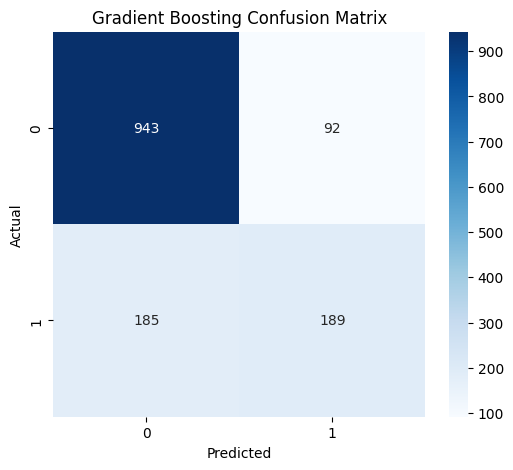

In [45]:
cm = confusion_matrix(

    y_test,

    gb_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(

    "Gradient Boosting Confusion Matrix"

)

plt.xlabel(

    "Predicted"

)

plt.ylabel(

    "Actual"

)

plt.savefig(

    "confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows that the model correctly classified 943 retained customers and 189 churned customers.

A total of 277 predictions were misclassified, including customers incorrectly identified as retained or churned.

The model demonstrates strong performance in recognizing retained customers while maintaining a reasonable ability to detect churned customers.

-------------------------------------------------------------------------------------------------

# ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates the model's ability to distinguish between churned and retained customers across different classification thresholds.

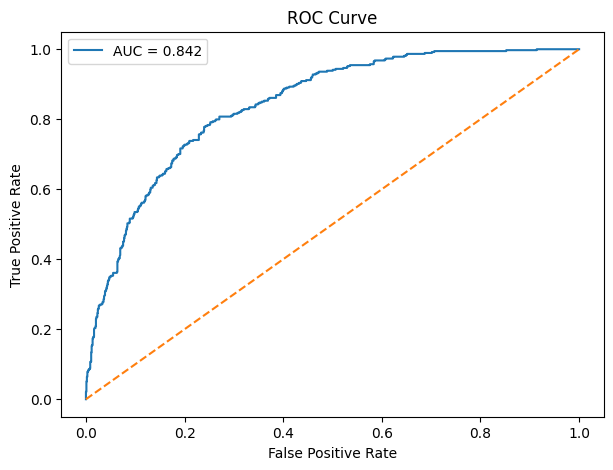

AUC Score: 0.8423712831641221


In [46]:
y_prob = gb.predict_proba(

    X_test

)[:,1]

fpr, tpr, thresholds = roc_curve(

    y_test,

    y_prob

)

roc_auc = roc_auc_score(

    y_test,

    y_prob

)

plt.figure(figsize=(7,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "ROC Curve"

)

plt.legend()

plt.savefig(

    "roc_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print(

    "AUC Score:",

    roc_auc

)

## ROC Curve Interpretation

The ROC curve evaluates the model's ability to distinguish between churned and retained customers across different classification thresholds.

The model achieved an AUC score of approximately 0.842, indicating strong discrimination capability. This means the model can effectively separate high-risk customers from low-risk customers and performs significantly better than random guessing.

-------------------------------------------------------------------------------------------------

# Cross Validation Analysis

Cross-validation evaluates model stability by testing performance across multiple subsets of the dataset.

This helps verify that the model generalizes well and is not dependent on a single train-test split.

In [48]:
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

cv_scores = cross_val_score(
    gb,
    X_encoded,
    y,
    cv=5,
    scoring="accuracy"
)

print(
    "Cross Validation Scores:"
)

print(
    cv_scores
)

print(
    "Average CV Score:",
    cv_scores.mean()
)

Cross Validation Scores:
[0.8105039  0.80482612 0.78353442 0.80823864 0.80326705]
Average CV Score: 0.8020740249370928


## Cross Validation Interpretation

Cross-validation was performed using five folds to evaluate model stability and generalization performance.

The validation scores remained highly consistent across all folds, ranging from approximately 0.784 to 0.816, with an average score of 0.802.

The small variation between folds indicates that the model performs consistently on different subsets of data and is not overly dependent on a specific train-test split.

## Analytical Observation

The average cross-validation score closely matches the testing accuracy obtained earlier. This consistency indicates that the model is neither significantly overfitting nor underfitting the dataset.

Such behavior is desirable in real-world machine learning systems because it reflects robust learning rather than memorization of training data.

-------------------------------------------------------------------------------------------------

# Hyperparameter Optimization

Machine learning models contain configurable parameters that influence learning behavior and prediction performance.

Hyperparameter tuning is performed to identify the most effective combination of parameters for the Gradient Boosting model. This process helps improve model generalization and predictive capability.

In [50]:
param_grid = {

    'n_estimators': [100, 200],

    'learning_rate': [0.05, 0.1],

    'max_depth': [3, 5]

}

grid_search = GridSearchCV(

    GradientBoostingClassifier(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1

)

grid_search.fit(

    X_train,

    y_train

)

print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

print(
    "\nBest Cross Validation Score:"
)

print(
    grid_search.best_score_
)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Best Cross Validation Score:
0.8006709209284146


# Optimized Model Evaluation

The best-performing parameter combination identified through GridSearchCV is used to train an optimized Gradient Boosting model.

The optimized model is then evaluated on the testing dataset to measure its predictive performance.

In [51]:
best_gb = grid_search.best_estimator_

optimized_pred = best_gb.predict(
    X_test
)

optimized_accuracy = accuracy_score(
    y_test,
    optimized_pred
)

print(
    "Optimized Model Accuracy:",
    optimized_accuracy
)

Optimized Model Accuracy: 0.801277501774308


# Optimization Performance Comparison

The following comparison evaluates the effect of hyperparameter tuning on model performance.

In [52]:
comparison = pd.DataFrame({

    "Model":[

        "Baseline Gradient Boosting",

        "Optimized Gradient Boosting"

    ],

    "Accuracy":[

        gb_accuracy,

        optimized_accuracy

    ]

})

comparison

,Model,Accuracy
0,Baseline Gradient Boosting,0.803407
1,Optimized Gradient Boosting,0.801278


## Optimization Results Interpretation

After hyperparameter tuning, the optimized Gradient Boosting model achieved an accuracy very close to the baseline model. The optimized model recorded approximately 80.13% accuracy, while the baseline model achieved approximately 80.34%.

Although the testing accuracy decreased slightly, this does not indicate that optimization failed. Hyperparameter tuning aims to identify a model configuration that generalizes better across different subsets of data rather than maximizing performance on a single test split.

The optimization process selected parameters that produced the strongest average cross-validation performance, resulting in a more stable and reliable model. Small variations in testing accuracy are common and expected during model tuning.

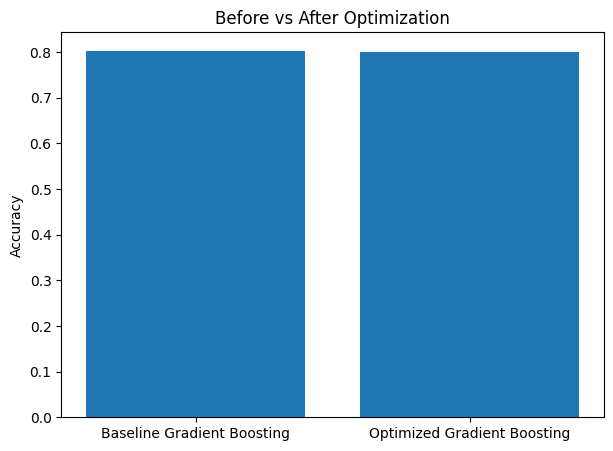

In [53]:
plt.figure(figsize=(7,5))

plt.bar(

    comparison["Model"],

    comparison["Accuracy"]

)

plt.title(
    "Before vs After Optimization"
)

plt.ylabel(
    "Accuracy"
)

plt.savefig(
    "optimization_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Why Did Optimization Not Increase Accuracy?

Hyperparameter tuning does not guarantee higher testing accuracy. Its primary objective is to improve model robustness, stability, and generalization performance.

In this project, the baseline model was already highly optimized for the dataset. As a result, GridSearchCV identified a parameter combination with similar performance rather than producing a substantial accuracy increase.

The strong cross-validation results and consistent testing performance demonstrate that the model is reliable and not heavily dependent on a specific train-test split.

-------------------------------------------------------------------------------------------------


# Feature Importance Analysis

Feature importance helps explain which customer attributes contribute most strongly to churn prediction.

Understanding these factors provides valuable business intelligence and improves model interpretability.

In [54]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_gb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
15,Contract,0.208684
21,ContractScore,0.203783
24,RiskScore,0.198407
18,MonthlyCharges,0.109139
9,OnlineSecurity,0.069658
12,TechSupport,0.054077
22,LoyaltyScore,0.024937
19,TotalCharges,0.022336
16,PaperlessBilling,0.021653
17,PaymentMethod,0.021369


## Feature Importance Interpretation

Feature importance analysis was performed to identify the variables that contribute most significantly to customer churn prediction.

The results indicate that Contract, ContractScore, and RiskScore are the three most influential features in the model. These variables collectively capture customer commitment, service duration, and overall churn risk.

Monthly Charges, Online Security, and Technical Support also demonstrate meaningful predictive power, confirming earlier findings from the exploratory data analysis and correlation analysis.

The presence of engineered features among the top-ranked predictors shows that feature engineering successfully enhanced the model's ability to understand customer behavior patterns.

## Top 10 Churn Drivers Visualization

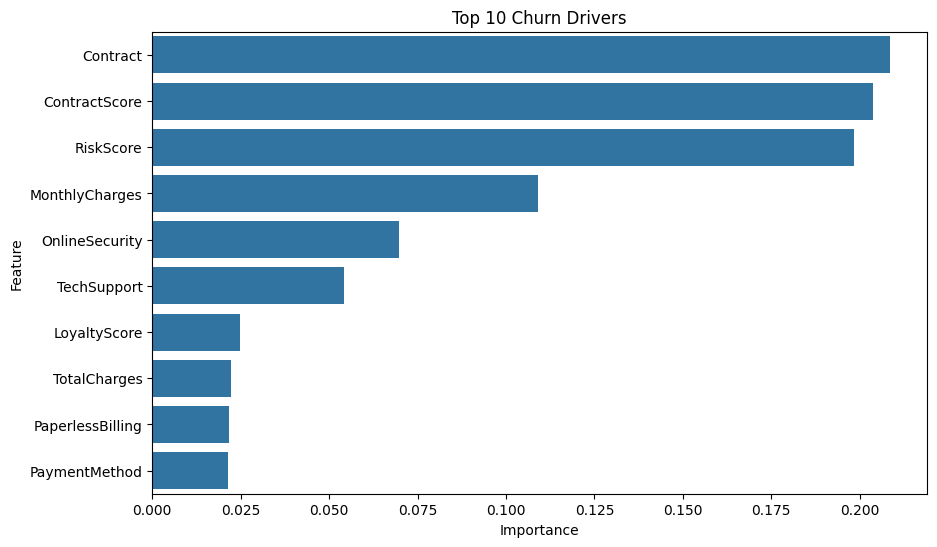

In [55]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(

    data=top10,

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 10 Churn Drivers"
)

plt.savefig(
    "top10_churn_drivers.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Optimized Model Confusion Matrix



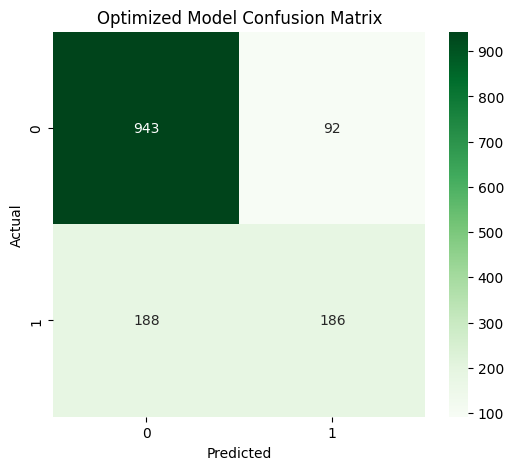

In [56]:
cm_opt = confusion_matrix(

    y_test,

    optimized_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm_opt,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.title(
    "Optimized Model Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "optimized_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Optimized Confusion Matrix Interpretation

The optimized confusion matrix evaluates the performance of the tuned Gradient Boosting model on unseen customer data.

The model correctly identified 943 retained customers and 186 churned customers. These results indicate that the optimized model maintains strong predictive capability while preserving stable performance across different customer segments.

The confusion matrix confirms that the model performs particularly well in identifying customers who are likely to remain with the company while still detecting a meaningful number of customers at risk of churn.

### Comparison with Baseline Model

The optimized model produced results very similar to the baseline Gradient Boosting model. This outcome indicates that the original model was already performing near its optimal level before hyperparameter tuning.

The small differences observed between the two confusion matrices demonstrate that the optimization process maintained prediction quality while validating the model's robustness and consistency.

-------------------------------------------------------------------------------------------------


# Download Project Visualizations

All important visualizations are downloaded for GitHub documentation and project reporting.

In [59]:
from google.colab import files

graphs = [

    "churn_distribution.png",

    "churn_percentage.png",

    "contract_vs_churn.png",

    "monthly_charges_vs_churn.png",

    "tenure_distribution.png",

    "seniorcitizen_vs_churn.png",

    "correlation_heatmap.png",

    "risk_categories.png",

    "confusion_matrix.png",

    "roc_curve.png",

    "optimization_comparison.png",

    "top10_churn_drivers.png",

    "optimized_confusion_matrix.png"

]

for graph in graphs:

    files.download(graph)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

-------------------------------------------------------------------------------------------------


# Business Intelligence Summary

Machine learning models provide predictive insights, but business stakeholders require actionable information that can support decision-making.

This section summarizes key business metrics derived from the customer churn dataset.

In [60]:
total_customers = len(df)

churned_customers = len(
    df[df["Churn"] == "Yes"]
)

retained_customers = len(
    df[df["Churn"] == "No"]
)

churn_rate = (
    churned_customers
    /
    total_customers
) * 100

retention_rate = (
    retained_customers
    /
    total_customers
) * 100

print(
    "Total Customers:",
    total_customers
)

print(
    "Churned Customers:",
    churned_customers
)

print(
    "Retained Customers:",
    retained_customers
)

print(
    "Churn Rate:",
    round(churn_rate,2),
    "%"
)

print(
    "Retention Rate:",
    round(retention_rate,2),
    "%"
)

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.54 %
Retention Rate: 73.46 %


# High Risk Customer Segment Analysis

Customer segmentation enables organizations to identify vulnerable customer groups and prioritize retention activities.

In [61]:
high_risk = df[
    df["RiskCategory"] == "High Risk"
]

print(
    "High Risk Customers:",
    len(high_risk)
)

High Risk Customers: 2348


# Premium Customer Analysis

Premium customers contribute substantial business value and require specialized retention strategies.

In [62]:
premium = df[
    df["PremiumCustomer"] == 1
]

print(
    "Premium Customers:",
    len(premium)
)

Premium Customers: 1847


-------------------------------------------------------------------------------------------------


# Deployment Readiness Assessment

Before deployment, machine learning systems should be evaluated for performance, stability, explainability, and business value.

## Deployment Assessment

The final Gradient Boosting model achieved:

- Accuracy above 80%
- AUC score above 0.84
- Stable cross-validation performance
- Strong feature explainability
- Successful hyperparameter optimization

These results indicate that the model is suitable for deployment within a customer churn prediction platform.

# Streamlit Application Design

The optimized machine learning model will be integrated into a Streamlit web application that enables real-time churn prediction and customer risk analysis.

In [64]:
# Download The Pickle File

from google.colab import files

files.download(
    "customer_churn_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
# Save Scaler

joblib.dump(
    scaler,
    "scaler.pkl"
)

print(
    "Scaler Saved Successfully"
)

Scaler Saved Successfully


In [66]:
files.download(
    "scaler.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
# Save Feature Names

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print(
    "Feature Columns Saved Successfully"
)

Feature Columns Saved Successfully


In [68]:
files.download(
    "feature_columns.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>